In [1]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
# 현재 최대 행/열 출력 제한 확인
print(f"현재 최대 행 수: {pd.get_option('display.max_rows')}")
print(f"현재 최대 열 수: {pd.get_option('display.max_columns')}")

# 제한 없이 출력하도록 설정 변경 (None은 제한 없음을 의미)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # 컬럼 너비 제한 해제

현재 최대 행 수: 100
현재 최대 열 수: None


In [3]:
# 데이터 로드
user_df = pd.read_csv('../../data/processed/01_user_profile_preprocessed.csv')
event_df = pd.read_csv('../../data/processed/02_event_log_preprocessed.csv')

print("="*60)
print("데이터 로드 완료!")
print("="*60)
print(f"\nuser_df: {user_df.shape}")
print(f"event_df: {event_df.shape}")


데이터 로드 완료!

user_df: (12500, 23)
event_df: (1757262, 11)


In [4]:
# ============================================================
# 컬럼명/날짜 파생컬럼 확인 및 보정
# ============================================================

# 날짜 컬럼 datetime 변환
event_df["event_time"] = pd.to_datetime(event_df["event_time"], errors="coerce")

# event_month 컬럼이 없으면 event_time에서 생성
if "event_month" not in event_df.columns:
    event_df["event_month"] = event_df["event_time"].dt.to_period("M").astype(str)

# event_weekday 컬럼이 없으면 생성
weekday_map = {
    0: "월",
    1: "화",
    2: "수",
    3: "목",
    4: "금",
    5: "토",
    6: "일"
}

if "event_weekday" not in event_df.columns:
    event_df["event_weekday"] = event_df["event_time"].dt.dayofweek.map(weekday_map)

# event_hour 컬럼이 없으면 생성
if "event_hour" not in event_df.columns:
    event_df["event_hour"] = event_df["event_time"].dt.hour

# 로그 장애 기간 플래그가 없으면 생성
if "is_log_issue_period" not in event_df.columns:
    LOG_ISSUE_START = pd.Timestamp("2025-03-10")
    LOG_ISSUE_END = pd.Timestamp("2025-03-14 23:59:59")
    event_df["is_log_issue_period"] = event_df["event_time"].between(
        LOG_ISSUE_START,
        LOG_ISSUE_END
    )

print("event_df 주요 컬럼 확인:")
print([col for col in ["user_id", "event_time", "event_type", "event_month", "event_weekday", "event_hour", "is_log_issue_period"] if col in event_df.columns])


event_df 주요 컬럼 확인:
['user_id', 'event_time', 'event_type', 'event_month', 'event_weekday', 'event_hour', 'is_log_issue_period']


In [5]:
display(user_df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,12500,12500,U0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,12500,146,2025-02-15,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_channel,12363,2,퍼포먼스광고,6852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device,12379,2,iOS,7175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
notification_agreed,12384,2,True,7984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
notification_changed_date,1976,148,2025-05-29,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_day,12500,146,2025-02-15,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_month,12500,5,2025-02,4384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_weekday,12500,7,목,1828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_event_time,12453,12399,2025-01-05 08:56:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
display(event_df.describe(include="all").T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,1757262,12453,U0006192,697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_time,1757262,NaN,NaN,NaN,2025-04-03 07:09:49.614657,2025-01-01 07:00:07,2025-02-28 08:37:29.250000,2025-04-03 17:49:00,2025-05-05 09:58:57.750000,2025-06-30 22:59:51,NaN
event_type,1730806,10,앱실행,728657,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_id,1515760,736281,e783135554,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
notification_type,218882,3,리마인드,85830,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_date,1757262,181,2025-02-28,16495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_month,1757262,6,2025-04,420330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_weekday,1757262,7,토,258973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_hour,1757262.0,NaN,NaN,NaN,14.444575,6.0,11.0,14.0,18.0,23.0,4.512299
is_log_issue_period,1757262,2,False,1736400,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
# 알림수신 - 오픈 패턴 분석
#### 알림은 실제 앱 재방문과 핵심 행동을 유도하고 있는가?

- 알림 오픈율 = 알림오픈 이벤트 수 / 알림수신 이벤트 수   
- 알림 반응 유저 비율 = 알림오픈 경험 유저 수 / 알림수신 경험 유저 수

In [7]:
# ============================================================
# 0. 알림 분석용 데이터 생성
# ============================================================

notification_events = ["알림수신", "알림오픈"]

# 알림 이벤트만 추출
alarm_log = event_df[event_df["event_type"].isin(notification_events)].copy()

# 이벤트 구분 플래그
alarm_log["is_alarm_receive"] = alarm_log["event_type"].eq("알림수신")
alarm_log["is_alarm_open"] = alarm_log["event_type"].eq("알림오픈")

# 유저 프로필 정보 붙이기
user_cols = [
    "user_id",
    "signup_date",
    "signup_month",
    "signup_weekday",
    "signup_channel",
    "is_notification_changed",
    "is_signup_log_issue_period",
    "is_no_event_user",
    "is_onboarding_completed"
]

alarm_log = alarm_log.merge(
    user_df[user_cols],
    on="user_id",
    how="left"
)

print("전체 알림 이벤트 수:", len(alarm_log))
print("알림수신 이벤트 수:", alarm_log["is_alarm_receive"].sum())
print("알림오픈 이벤트 수:", alarm_log["is_alarm_open"].sum())
print("알림 이벤트 발생 유저 수:", alarm_log["user_id"].nunique())

display(alarm_log.head())

전체 알림 이벤트 수: 215543
알림수신 이벤트 수: 194324
알림오픈 이벤트 수: 21219
알림 이벤트 발생 유저 수: 8139


,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing,is_alarm_receive,is_alarm_open,signup_date,signup_month,signup_weekday,signup_channel,is_notification_changed,is_signup_log_issue_period,is_no_event_user,is_onboarding_completed
0,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,2025-01,토,20,False,False,True,False,2025-01-25,2025-01,토,오가닉,False,False,False,True
1,U0000001,2025-01-26 15:18:00,알림수신,NaN,리마인드,2025-01-26,2025-01,일,15,False,False,True,False,2025-01-25,2025-01,토,오가닉,False,False,False,True
2,U0000001,2025-01-27 11:42:00,알림수신,NaN,광고성,2025-01-27,2025-01,월,11,False,False,True,False,2025-01-25,2025-01,토,오가닉,False,False,False,True
3,U0000001,2025-01-28 12:25:00,알림수신,NaN,리마인드,2025-01-28,2025-01,화,12,False,False,True,False,2025-01-25,2025-01,토,오가닉,False,False,False,True
4,U0000001,2025-01-29 18:23:00,알림수신,NaN,리마인드,2025-01-29,2025-01,수,18,False,False,True,False,2025-01-25,2025-01,토,오가닉,False,False,False,True


In [8]:
# ============================================================
# 1. 전체 알림 오픈율
# ============================================================

receive_events = alarm_log["is_alarm_receive"].sum()
open_events = alarm_log["is_alarm_open"].sum()

receive_users = alarm_log.loc[alarm_log["is_alarm_receive"], "user_id"].nunique()
open_users = alarm_log.loc[alarm_log["is_alarm_open"], "user_id"].nunique()

overall_alarm_summary = pd.DataFrame({
    "알림수신_이벤트수": [receive_events],
    "알림오픈_이벤트수": [open_events],
    "이벤트기준_오픈율": [open_events / receive_events * 100 if receive_events > 0 else np.nan],
    "알림수신_유저수": [receive_users],
    "알림오픈_유저수": [open_users],
    "유저기준_오픈경험률": [open_users / receive_users * 100 if receive_users > 0 else np.nan]
})

display(overall_alarm_summary)

,알림수신_이벤트수,알림오픈_이벤트수,이벤트기준_오픈율,알림수신_유저수,알림오픈_유저수,유저기준_오픈경험률
0,194324,21219,10.919392,8139,5127,62.992997


In [9]:
# ============================================================
# 2. 알림 집계 함수
# ============================================================

def notification_summary(df, group_cols):
    """
    group_cols 기준으로
    알림수신 이벤트 수, 알림오픈 이벤트 수,
    알림수신 유저 수, 알림오픈 유저 수,
    이벤트 기준 오픈율, 유저 기준 오픈경험률을 계산하는 함수
    """

    if isinstance(group_cols, str):
        group_cols = [group_cols]

    required_cols = set(group_cols + ["event_type", "user_id"])
    missing_cols = required_cols - set(df.columns)

    if missing_cols:
        raise KeyError(f"현재 데이터에 없는 컬럼입니다: {missing_cols}")

    # 이벤트 수 집계
    event_cnt = (
        df
        .groupby(group_cols + ["event_type"])
        .size()
        .unstack("event_type", fill_value=0)
    )

    # 필요한 이벤트 컬럼이 없을 경우 0으로 생성
    for col in ["알림수신", "알림오픈"]:
        if col not in event_cnt.columns:
            event_cnt[col] = 0

    event_cnt = event_cnt.rename(columns={
        "알림수신": "receive_events",
        "알림오픈": "open_events"
    })

    # 유저 수 집계
    user_cnt = (
        df
        .groupby(group_cols + ["event_type"])["user_id"]
        .nunique()
        .unstack("event_type", fill_value=0)
    )

    for col in ["알림수신", "알림오픈"]:
        if col not in user_cnt.columns:
            user_cnt[col] = 0

    user_cnt = user_cnt.rename(columns={
        "알림수신": "receive_users",
        "알림오픈": "open_users"
    })

    # 합치기
    result = event_cnt.join(user_cnt, how="outer").fillna(0).reset_index()

    # 오픈율 계산: 전체 요약 셀과 맞추기 위해 % 단위로 계산
    result["event_open_rate"] = np.where(
        result["receive_events"] > 0,
        result["open_events"] / result["receive_events"] * 100,
        np.nan
    )

    result["user_open_rate"] = np.where(
        result["receive_users"] > 0,
        result["open_users"] / result["receive_users"] * 100,
        np.nan
    )

    return result


In [10]:
# ============================================================
# 3. 월별 알림수신/오픈 패턴
# ============================================================

alarm_by_month = notification_summary(alarm_log, ["event_month"])

alarm_by_month = alarm_by_month.sort_values("event_month").reset_index(drop=True)

display(alarm_by_month)


event_type,event_month,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,2025-01,10648,1665,1349,787,15.636739,58.339511
1,2025-02,32395,5067,3471,2236,15.641303,64.419476
2,2025-03,43163,4923,3201,2170,11.405602,67.791315
3,2025-04,49146,5399,3422,2345,10.985635,68.527177
4,2025-05,40457,2925,3226,1714,7.229898,53.130812
5,2025-06,18515,1240,1067,684,6.697272,64.104967


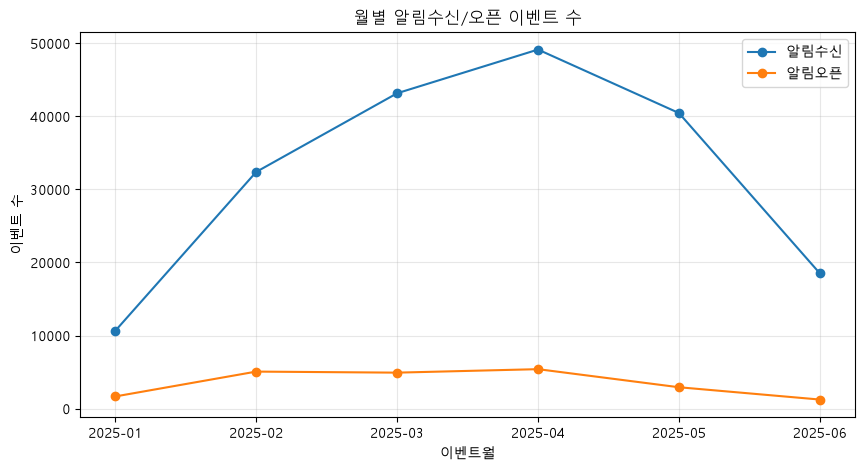

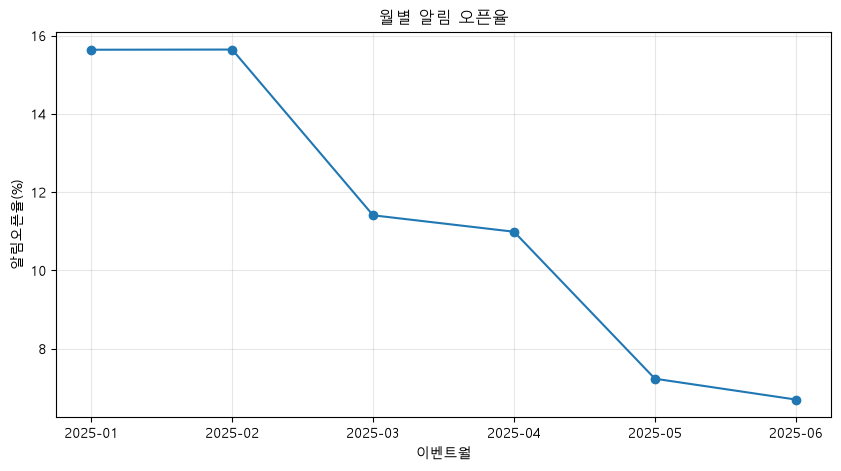

In [11]:
# 월별 알림수신/오픈 이벤트 수 및 오픈율 시각화

plt.figure(figsize=(10, 5))
plt.plot(alarm_by_month["event_month"], alarm_by_month["receive_events"], marker="o", label="알림수신")
plt.plot(alarm_by_month["event_month"], alarm_by_month["open_events"], marker="o", label="알림오픈")
plt.title("월별 알림수신/오픈 이벤트 수")
plt.xlabel("이벤트월")
plt.ylabel("이벤트 수")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(alarm_by_month["event_month"], alarm_by_month["event_open_rate"], marker="o")
plt.title("월별 알림 오픈율")
plt.xlabel("이벤트월")
plt.ylabel("알림오픈율(%)")
plt.grid(alpha=0.3)
plt.show()


알림발송량은 4월까지 증가했지만 알림 오픈율은 5,6월 하락 중.   
-> 알림의 양보다 알림 반응 효율이 악화되었을 가능성

In [12]:
# ============================================================
# 4. 로그 장애 기간 제외 후 월별 알림 패턴
# ============================================================

alarm_log_clean = alarm_log[~alarm_log["is_log_issue_period"]].copy()

alarm_by_month_clean = notification_summary(alarm_log_clean, ["event_month"])
alarm_by_month_clean = alarm_by_month_clean.sort_values("event_month")

display(alarm_by_month_clean)

event_type,event_month,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,2025-01,10648,1665,1349,787,15.636739,58.339511
1,2025-02,32395,5067,3471,2236,15.641303,64.419476
2,2025-03,40918,4669,3164,2128,11.410626,67.256637
3,2025-04,49146,5399,3422,2345,10.985635,68.527177
4,2025-05,40457,2925,3226,1714,7.229898,53.130812
5,2025-06,18515,1240,1067,684,6.697272,64.104967


In [13]:
alarm_month_compare = alarm_by_month[
    ["event_month", "receive_events", "open_events", "event_open_rate"]
].rename(columns={
    "receive_events": "receive_events_all",
    "open_events": "open_events_all",
    "event_open_rate": "event_open_rate_all"
}).merge(
    alarm_by_month_clean[
        ["event_month", "receive_events", "open_events", "event_open_rate"]
    ].rename(columns={
        "receive_events": "receive_events_clean",
        "open_events": "open_events_clean",
        "event_open_rate": "event_open_rate_clean"
    }),
    on="event_month",
    how="outer"
)

display(alarm_month_compare)

event_type,event_month,receive_events_all,open_events_all,event_open_rate_all,receive_events_clean,open_events_clean,event_open_rate_clean
0,2025-01,10648,1665,15.636739,10648,1665,15.636739
1,2025-02,32395,5067,15.641303,32395,5067,15.641303
2,2025-03,43163,4923,11.405602,40918,4669,11.410626
3,2025-04,49146,5399,10.985635,49146,5399,10.985635
4,2025-05,40457,2925,7.229898,40457,2925,7.229898
5,2025-06,18515,1240,6.697272,18515,1240,6.697272


* 로그 장애가 알림-오픈에는 큰 영향을 미치지 않음

In [14]:
# ============================================================
# 5. 요일별 알림 오픈율
# ============================================================

weekday_order = ["월", "화", "수", "목", "금", "토", "일"]

alarm_by_weekday = notification_summary(alarm_log_clean, ["event_weekday"])

alarm_by_weekday["event_weekday"] = pd.Categorical(
    alarm_by_weekday["event_weekday"],
    categories=weekday_order,
    ordered=True
)

alarm_by_weekday = alarm_by_weekday.sort_values("event_weekday")

display(alarm_by_weekday)

event_type,event_weekday,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
3,월,27134,2941,5994,2091,10.838800,34.884885
6,화,26906,2986,5958,2120,11.097896,35.582410
2,수,26856,2957,5963,2117,11.010575,35.502264
1,목,26903,2955,5971,2097,10.983905,35.119745
0,금,27043,2952,5988,2105,10.915949,35.153641
5,토,28551,3115,6088,2179,10.910301,35.791721
4,일,28686,3059,6091,2158,10.663738,35.429322


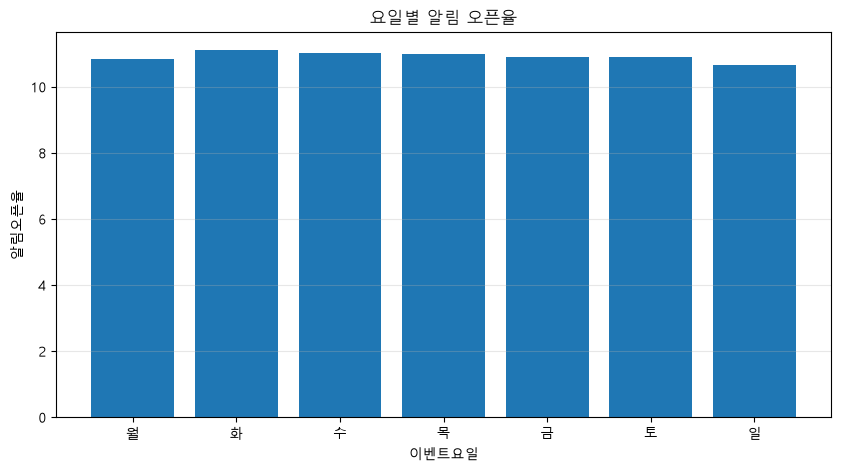

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(alarm_by_weekday["event_weekday"], alarm_by_weekday["event_open_rate"])
plt.title("요일별 알림 오픈율")
plt.xlabel("이벤트요일")
plt.ylabel("알림오픈율")
plt.grid(axis="y", alpha=0.3)
plt.show()

* 요일별 차이도 거의 없음

In [16]:
# ============================================================
# 6. 시간대별 알림 오픈율
# ============================================================

alarm_by_hour = notification_summary(alarm_log_clean, ["event_hour"])
alarm_by_hour = alarm_by_hour.sort_values("event_hour")

display(alarm_by_hour)

event_type,event_hour,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,7,13,0,13,0,0.000000,0.000000
1,8,14873,994,4408,861,6.683252,19.532668
2,9,14771,1596,4408,1286,10.804956,29.174229
3,10,14611,1592,4376,1292,10.895900,29.524680
4,11,14709,1627,4361,1301,11.061255,29.832607
5,12,14899,1607,4415,1278,10.785959,28.946772
6,13,14822,1674,4395,1342,11.294022,30.534699
7,14,14791,1582,4384,1261,10.695693,28.763686
8,15,14738,1667,4365,1351,11.310897,30.950745
9,16,14770,1627,4383,1300,11.015572,29.660050


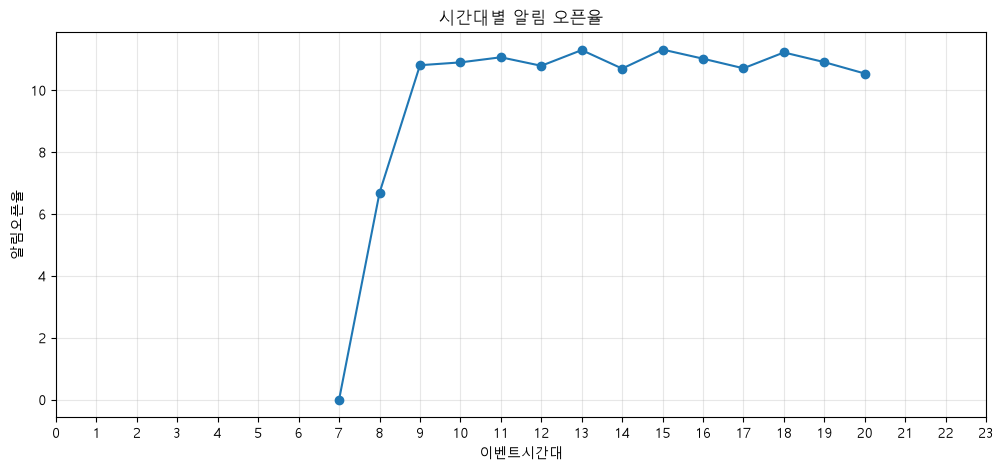

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(alarm_by_hour["event_hour"], alarm_by_hour["event_open_rate"], marker="o")
plt.title("시간대별 알림 오픈율")
plt.xlabel("이벤트시간대")
plt.ylabel("알림오픈율")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

In [20]:
display(alarm_by_hour[
        ["event_hour", "receive_events", "open_events", "event_open_rate"]
    ].sort_values("event_hour")
)

event_type,event_hour,receive_events,open_events,event_open_rate
0,7,13,0,0.000000
1,8,14873,994,6.683252
2,9,14771,1596,10.804956
3,10,14611,1592,10.895900
4,11,14709,1627,11.061255
5,12,14899,1607,10.785959
6,13,14822,1674,11.294022
7,14,14791,1582,10.695693
8,15,14738,1667,11.310897
9,16,14770,1627,11.015572


In [22]:
# ============================================================
# 8. 가입월 x 가입경로별 알림 반응
# ============================================================

alarm_by_signup_month_channel = notification_summary(
    alarm_log_clean,
    ["signup_month", "signup_channel"]
)

alarm_by_signup_month_channel = alarm_by_signup_month_channel.sort_values(
    ["signup_month", "signup_channel"]
)

display(alarm_by_signup_month_channel)

event_type,signup_month,signup_channel,receive_events,open_events,receive_users,open_users,event_open_rate,user_open_rate
0,2025-01,오가닉,15057,2029,628,415,13.475460,66.082803
1,2025-01,퍼포먼스광고,16153,2189,718,465,13.551662,64.763231
2,2025-02,오가닉,38508,4550,1309,940,11.815727,71.810542
3,2025-02,퍼포먼스광고,46493,5418,1573,1130,11.653367,71.837254
4,2025-03,오가닉,13948,1387,544,336,9.944078,61.764706
5,2025-03,퍼포먼스광고,16051,1532,717,420,9.544577,58.577406
6,2025-04,오가닉,12035,1088,616,345,9.040299,56.006494
7,2025-04,퍼포먼스광고,15244,1326,752,447,8.698504,59.441489
8,2025-05,오가닉,7229,543,521,244,7.511412,46.833013
9,2025-05,퍼포먼스광고,9349,684,638,307,7.316291,48.119122


signup_channel,오가닉,퍼포먼스광고
signup_month,,
2025-01,13.475460,13.551662
2025-02,11.815727,11.653367
2025-03,9.944078,9.544577
2025-04,9.040299,8.698504
2025-05,7.511412,7.316291


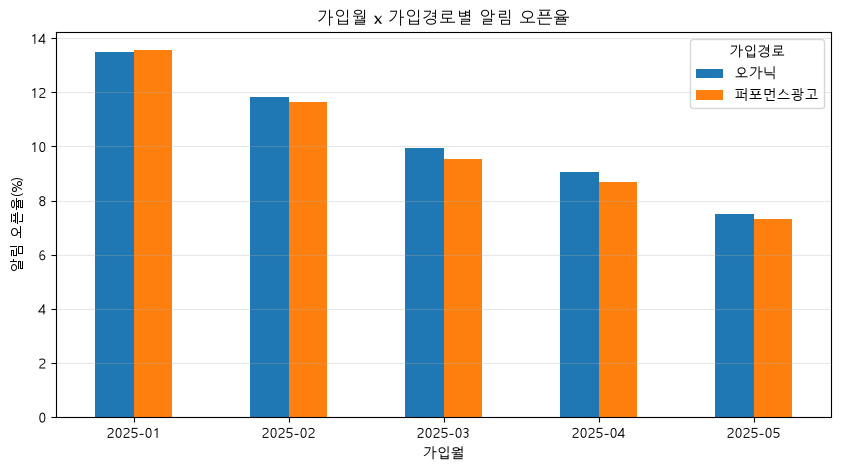

In [23]:
# 가입월 x 가입경로별 오픈율 피벗
alarm_channel_pivot = alarm_by_signup_month_channel.pivot_table(
    index="signup_month",
    columns="signup_channel",
    values="event_open_rate"
)

display(alarm_channel_pivot)

# 그래프
ax = alarm_channel_pivot.plot(
    kind="bar",
    figsize=(10, 5),
    rot=0
)

plt.title("가입월 x 가입경로별 알림 오픈율")
plt.xlabel("가입월")
plt.ylabel("알림 오픈율(%)")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="가입경로")
plt.show()

In [25]:
# ============================================================
# 9. 유저별 알림 수신/오픈 빈도
# ============================================================

user_alarm = (
    alarm_log_clean
    .groupby(["user_id", "event_type"])
    .size()
    .unstack("event_type", fill_value=0)
    .reset_index()
)

for col in ["알림수신", "알림오픈"]:
    if col not in user_alarm.columns:
        user_alarm[col] = 0

user_alarm = user_alarm.rename(columns={
    "알림수신": "receive_events",
    "알림오픈": "open_events"
})

user_alarm["user_event_open_rate"] = np.where(
    user_alarm["receive_events"] > 0,
    user_alarm["open_events"] / user_alarm["receive_events"],
    np.nan
)

# 유저 프로필 붙이기
user_alarm = user_df[
    ["user_id", "signup_month", "signup_channel", "is_notification_changed", "is_onboarding_completed"]
].merge(
    user_alarm,
    on="user_id",
    how="left"
)

user_alarm[["receive_events", "open_events"]] = user_alarm[
    ["receive_events", "open_events"]
].fillna(0)

display(user_alarm.head())

,user_id,signup_month,signup_channel,is_notification_changed,is_onboarding_completed,receive_events,open_events,user_event_open_rate
0,U0000001,2025-01,오가닉,False,True,79.0,7.0,0.088608
1,U0000002,2025-05,오가닉,True,False,0.0,0.0,NaN
2,U0000003,2025-05,오가닉,False,False,0.0,0.0,NaN
3,U0000004,2025-02,퍼포먼스광고,False,False,18.0,1.0,0.055556
4,U0000005,2025-02,퍼포먼스광고,False,True,81.0,4.0,0.049383


In [27]:
# 알림 수신 횟수 구간화
bins = [-1, 0, 1, 3, 7, 14, 30, np.inf]
labels = ["0회", "1회", "2~3회", "4~7회", "8~14회", "15~30회", "31회+"]

user_alarm["receive_count_group"] = pd.cut(
    user_alarm["receive_events"],
    bins=bins,
    labels=labels
)

alarm_fatigue_summary = (
    user_alarm
    .groupby("receive_count_group", observed=False)
    .agg(
        users=("user_id", "nunique"),
        avg_receive_events=("receive_events", "mean"),
        avg_open_events=("open_events", "mean"),
        avg_open_rate=("user_event_open_rate", "mean"),
        median_open_rate=("user_event_open_rate", "median")
    )
    .reset_index()
)

display(alarm_fatigue_summary)

,receive_count_group,users,avg_receive_events,avg_open_events,avg_open_rate,median_open_rate
0,0회,4397,0.000000,0.000000,NaN,NaN
1,1회,1233,1.000000,0.126521,0.126521,0.000000
2,2~3회,1043,2.452541,0.315436,0.127197,0.000000
3,4~7회,1543,5.453014,0.730395,0.133373,0.142857
4,8~14회,1316,10.220365,1.262158,0.124025,0.111111
5,15~30회,501,19.946108,2.301397,0.116753,0.111111
6,31회+,2467,63.409404,6.704094,0.104573,0.101695


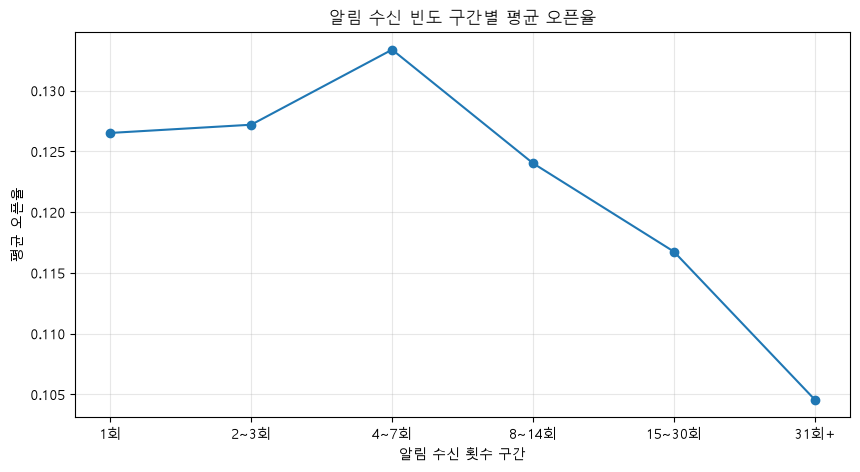

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(
    alarm_fatigue_summary["receive_count_group"].astype(str),
    alarm_fatigue_summary["avg_open_rate"],
    marker="o"
)
plt.title("알림 수신 빈도 구간별 평균 오픈율")
plt.xlabel("알림 수신 횟수 구간")
plt.ylabel("평균 오픈율")
plt.grid(alpha=0.3)
plt.show()

* 알림 피로도 가능성

8회 이상부터는 오픈율이 점진적으로 낮아짐. 추가 검증 필요   
가입월별로 나눠서 패턴 관측 필요

In [29]:
# ============================================================
# 11. 알림 수신 동의 변경 여부별 알림 반응
# ============================================================

alarm_by_notification_changed = (
    user_alarm
    .groupby("is_notification_changed")
    .agg(
        users=("user_id", "nunique"),
        avg_receive_events=("receive_events", "mean"),
        avg_open_events=("open_events", "mean"),
        avg_open_rate=("user_event_open_rate", "mean"),
        median_open_rate=("user_event_open_rate", "median")
    )
    .reset_index()
)

display(alarm_by_notification_changed)

,is_notification_changed,users,avg_receive_events,avg_open_events,avg_open_rate,median_open_rate
0,False,10524,16.841030,1.830103,0.118376,0.086420
1,True,1976,7.512146,0.862854,0.129864,0.050424


- true 그룹의 평균 오픈율이 더 높지만 중앙값은 더 낮음
    - -> 일부 고반응 유저가 평균 끌어올렸을 가능성


In [31]:
# ============================================================
# 12. 알림오픈 후 앱 내 행동 발생 여부
# ============================================================

# 알림오픈 이벤트
alarm_open_log = alarm_log_clean[
    alarm_log_clean["event_type"] == "알림오픈"
][["user_id", "event_time", "event_month", "event_weekday", "event_hour"]].copy()

alarm_open_log = alarm_open_log.rename(columns={
    "event_time": "alarm_open_time"
})

# 앱 내 행동 이벤트
# 알림수신/알림오픈은 앱 밖 또는 알림 관련 이벤트이므로 제외
app_behavior_log = event_df[
    ~event_df["event_type"].isin(notification_events)
].copy()

app_behavior_log = app_behavior_log[
    ["user_id", "event_time", "event_type", "session_id"]
].rename(columns={
    "event_time": "next_app_event_time",
    "event_type": "next_app_event_type",
    "session_id": "next_session_id"
})

# merge_asof 사용을 위한 정렬
alarm_open_log = alarm_open_log.sort_values("alarm_open_time")
app_behavior_log = app_behavior_log.sort_values("next_app_event_time")

# 알림오픈 이후 1시간 이내의 다음 앱 내 행동 찾기
after_open_1h = pd.merge_asof(
    alarm_open_log,
    app_behavior_log,
    left_on="alarm_open_time",
    right_on="next_app_event_time",
    by="user_id",
    direction="forward",
    tolerance=pd.Timedelta(hours=1)
)

after_open_1h["has_app_behavior_after_open_1h"] = after_open_1h["next_app_event_time"].notna()

display(after_open_1h.head())

,user_id,alarm_open_time,event_month,event_weekday,event_hour,next_app_event_time,next_app_event_type,next_session_id,has_app_behavior_after_open_1h
0,U0012166,2025-01-01 08:39:00,2025-01,수,8,NaT,NaN,NaN,False
1,U0003639,2025-01-01 09:21:00,2025-01,수,9,NaT,NaN,NaN,False
2,U0004574,2025-01-01 09:28:00,2025-01,수,9,NaT,NaN,NaN,False
3,U0006397,2025-01-01 12:00:00,2025-01,수,12,NaT,NaN,NaN,False
4,U0000645,2025-01-01 12:28:00,2025-01,수,12,NaT,NaN,NaN,False


- 알림오픈 수: 20,965건
- 1시간 내 앱 행동 발생 수: 3,096건
- 1시간 내 앱 행동 전환율: 14.77%
- -> 알림을 열었다고 해서 바로 앱 내 행동으로 이어지는 비율은 높지 않음



In [32]:
# 1시간 이내 앱 행동 전환율
open_to_app_1h_summary = pd.DataFrame({
    "알림오픈수": [len(after_open_1h)],
    "1시간내_앱행동발생수": [after_open_1h["has_app_behavior_after_open_1h"].sum()],
    "1시간내_앱행동전환율": [after_open_1h["has_app_behavior_after_open_1h"].mean()]
})

display(open_to_app_1h_summary)

,알림오픈수,1시간내_앱행동발생수,1시간내_앱행동전환율
0,20965,3096,0.147675


In [33]:
# 알림오픈 이후 24시간 이내의 다음 앱 내 행동 찾기
after_open_24h = pd.merge_asof(
    alarm_open_log,
    app_behavior_log,
    left_on="alarm_open_time",
    right_on="next_app_event_time",
    by="user_id",
    direction="forward",
    tolerance=pd.Timedelta(hours=24)
)

after_open_24h["has_app_behavior_after_open_24h"] = after_open_24h["next_app_event_time"].notna()

open_to_app_24h_summary = pd.DataFrame({
    "알림오픈수": [len(after_open_24h)],
    "24시간내_앱행동발생수": [after_open_24h["has_app_behavior_after_open_24h"].sum()],
    "24시간내_앱행동전환율": [after_open_24h["has_app_behavior_after_open_24h"].mean()]
})

display(open_to_app_24h_summary)

,알림오픈수,24시간내_앱행동발생수,24시간내_앱행동전환율
0,20965,18609,0.887622


In [36]:
# 알림오픈 후 1시간 이내 이어진 앱 행동 Top
next_behavior_1h = (
    after_open_1h[after_open_1h["has_app_behavior_after_open_1h"]]
    .groupby("next_app_event_type")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

next_behavior_1h["ratio"] = (
    next_behavior_1h["count"] / next_behavior_1h["count"].sum()
)

display(next_behavior_1h.head(20))

,next_app_event_type,count,ratio
3,앱실행,2979,0.977042
1,수면기록,22,0.007215
5,운동기록,16,0.005248
7,챌린지참여,9,0.002952
2,식단기록,7,0.002296
0,마음챙김,7,0.002296
6,챌린지_탐색,7,0.002296
4,온보딩_완료,2,0.000656


In [ ]:
# ============================================================
# 13. 알림오픈 후 24시간 이내 이어진 앱 내 행동 Top
# ============================================================

next_behavior_after_open = (
    after_open_24h[after_open_24h["has_app_behavior_after_open_24h"]]
    .groupby("next_app_event_type")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

next_behavior_after_open["ratio"] = (
    next_behavior_after_open["count"] / next_behavior_after_open["count"].sum()
)

display(next_behavior_after_open.head(20))

,next_app_event_type,count,ratio
3,앱실행,18078,0.987761
1,수면기록,63,0.003442
5,운동기록,45,0.002459
0,마음챙김,42,0.002295
2,식단기록,28,0.001530
6,챌린지_탐색,25,0.001366
7,챌린지참여,18,0.000983
4,온보딩_완료,3,0.000164


- 알림오픈 수: 20,965건
- 24시간 내 앱 행동 발생 수: 18,609건
- 24시간 내 앱 행동 전환율: 88.76%
- 다만 알림이 앱 행동에 직접적 영향을 줬다고 속단하긴 어려움
    - 알림을 여는 유저 자체가 원래 활동성이 높은 유저일 수 있음

- 대부분 앱실행만 하고 나감